In [9]:
import subprocess
subprocess.check_call(["pip", "install", "opencv-python-headless", "matplotlib", "numpy", "pillow"])


[notice] A new release of pip available: 22.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


0

# Object Extraction Using Thresholding Techniques

**Assignment:** Extract objects from a homogenous background using various thresholding methods.

**Setup:** Three everyday objects (a red apple, a blue book, and a yellow banana) were placed on a plain light-gray background and photographed. This notebook demonstrates multiple thresholding approaches to segment the objects from the background.

---

### Techniques Covered
1. Global / Simple Binary Thresholding
2. Otsu's Automatic Thresholding
3. Adaptive Mean Thresholding
4. Adaptive Gaussian Thresholding
5. HSV Color-Range Thresholding (per-object)
6. Combined / Multi-Channel Thresholding

## 1. Setup & Imports

In [10]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# ── helper: display up to 6 images in a grid ─────────────────────────────────
def show_images(images, titles, rows=2, cols=3, figsize=(15, 9), cmap_default='gray'):
    """Utility to plot a grid of OpenCV images with titles."""
    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    axes = axes.flatten()
    for ax, img, title in zip(axes, images, titles):
        if len(img.shape) == 3:          # colour → convert BGR→RGB for matplotlib
            ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        else:                            # grayscale / binary
            ax.imshow(img, cmap=cmap_default)
        ax.set_title(title, fontsize=11, fontweight='bold')
        ax.axis('off')
    for ax in axes[len(images):]:
        ax.axis('off')
    plt.tight_layout()
    plt.show()

print('Libraries loaded ✓')

Libraries loaded ✓


## 2. Load the Input Image

Image loaded → shape: (4032, 3024, 3)  dtype: uint8


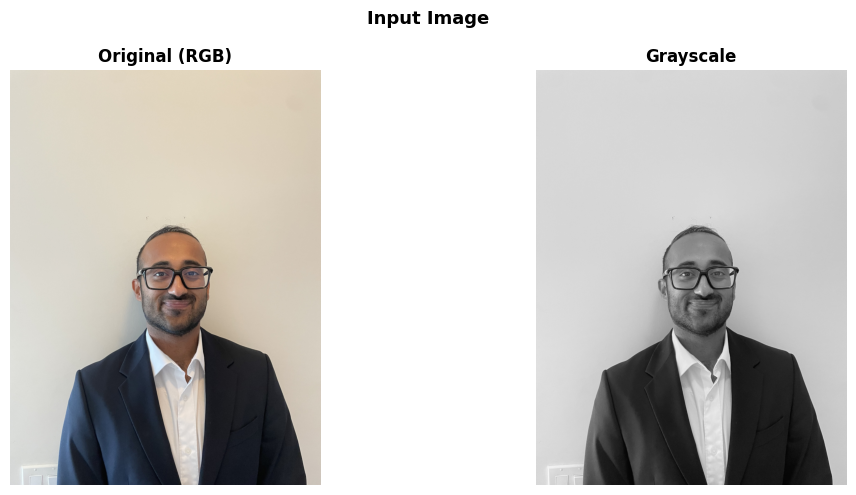

In [14]:
# ── Load image ────────────────────────────────────────────────────────────────
# Replace 'sample_objects.jpg' with your own photo filename if needed.
IMAGE_PATH = 'sample_objects.jpeg'

img_bgr  = cv2.imread(IMAGE_PATH)          # original colour (BGR)
if img_bgr is None:
    raise FileNotFoundError(f"Could not read '{IMAGE_PATH}'. Check the path.")

img_rgb  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)   # for display
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)  # for most threshold ops
img_hsv  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)   # for colour-range thresh

print(f'Image loaded → shape: {img_bgr.shape}  dtype: {img_bgr.dtype}')

# Show the original and its grayscale version side-by-side
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1); plt.imshow(img_rgb);  plt.title('Original (RGB)', fontweight='bold'); plt.axis('off')
plt.subplot(1, 2, 2); plt.imshow(img_gray, cmap='gray'); plt.title('Grayscale', fontweight='bold'); plt.axis('off')
plt.suptitle('Input Image', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

## 3. Grayscale Intensity Histogram

Before choosing a threshold value it helps to look at the pixel-intensity histogram.  
A clear **valley** between object and background peaks signals a good manual threshold.

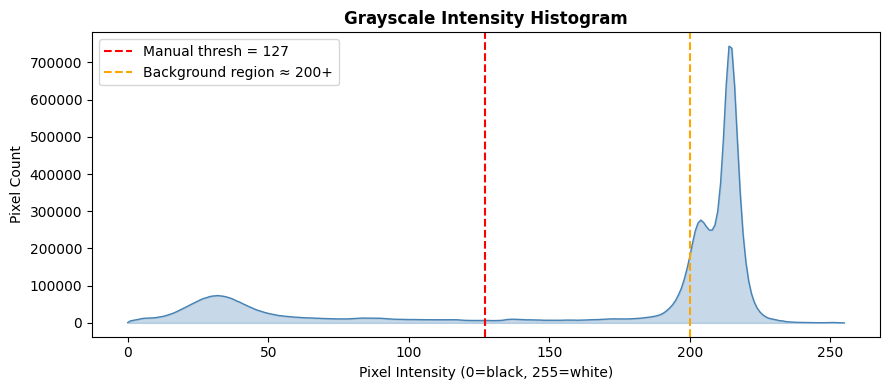

Observations:
  Mean intensity : 169.8
  Std deviation  : 71.1
  Dark pixels (<100): 2,647,617
  Light pixels (>200): 7,897,282


In [15]:
hist = cv2.calcHist([img_gray], [0], None, [256], [0, 256]).flatten()

plt.figure(figsize=(9, 4))
plt.plot(hist, color='steelblue', linewidth=1)
plt.fill_between(range(256), hist, alpha=0.3, color='steelblue')
plt.axvline(x=127, color='red',    linestyle='--', label='Manual thresh = 127')
plt.axvline(x=200, color='orange', linestyle='--', label='Background region ≈ 200+')
plt.xlabel('Pixel Intensity (0=black, 255=white)')
plt.ylabel('Pixel Count')
plt.title('Grayscale Intensity Histogram', fontweight='bold')
plt.legend(); plt.tight_layout(); plt.show()

print('Observations:')
print(f'  Mean intensity : {img_gray.mean():.1f}')
print(f'  Std deviation  : {img_gray.std():.1f}')
print(f'  Dark pixels (<100): {(img_gray < 100).sum():,}')
print(f'  Light pixels (>200): {(img_gray > 200).sum():,}')

## 4. Technique 1 — Global Binary Thresholding

The simplest approach: choose a single intensity value `T`.  
Every pixel **below** T → foreground (object); every pixel **above** T → background.

**Best when:** the background is uniform and the object brightness is clearly different from the background.

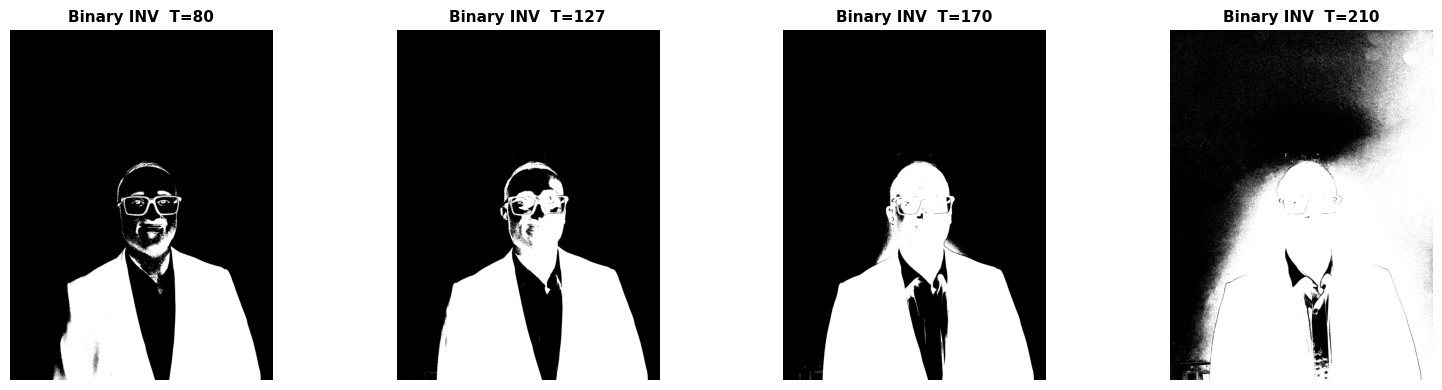

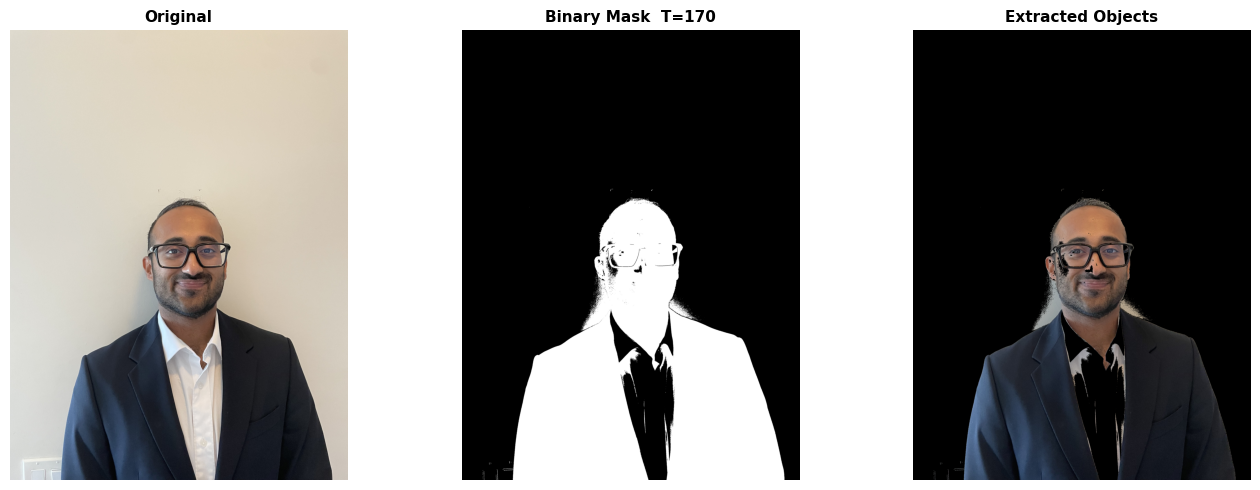

Global threshold chosen: T = 170


In [16]:
# cv2.threshold(src, thresh, maxval, type)
# THRESH_BINARY_INV → objects become white (255), background becomes black (0)

results, titles = [], []
for T in [80, 127, 170, 210]:
    _, mask = cv2.threshold(img_gray, T, 255, cv2.THRESH_BINARY_INV)
    results.append(mask)
    titles.append(f'Binary INV  T={T}')

show_images(results, titles, rows=1, cols=4, figsize=(16, 4))

# Pick the best threshold visually (T=170 works well for this image)
BEST_T = 170
_, best_global = cv2.threshold(img_gray, BEST_T, 255, cv2.THRESH_BINARY_INV)

# Apply mask to colour image to show extracted objects
extracted_global = cv2.bitwise_and(img_bgr, img_bgr, mask=best_global)

show_images(
    [img_bgr, best_global, extracted_global],
    ['Original', f'Binary Mask  T={BEST_T}', 'Extracted Objects'],
    rows=1, cols=3, figsize=(14, 5)
)
print(f'Global threshold chosen: T = {BEST_T}')

## 5. Technique 2 — Otsu's Automatic Thresholding

Otsu's method **automatically** calculates the optimal global threshold by minimising the intra-class variance (equivalently, maximising inter-class variance) of the foreground and background pixel groups.

**Best when:** the histogram shows two distinct peaks (bimodal).

Otsu's optimal threshold: 126
Otsu's threshold (after blur): 127


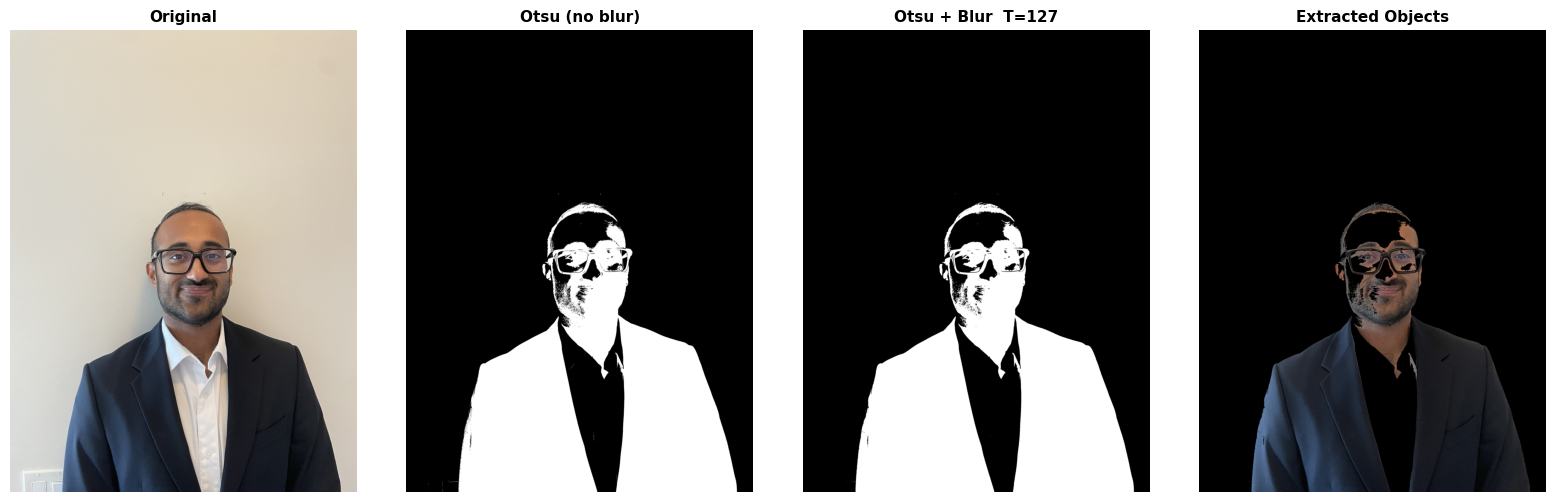

In [17]:
# Pass thresh=0 + THRESH_OTSU → OpenCV computes the optimal T automatically
otsu_T, mask_otsu = cv2.threshold(
    img_gray, 0, 255,
    cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
)
print(f"Otsu's optimal threshold: {otsu_T:.0f}")

# Optional: apply slight Gaussian blur before Otsu to reduce noise
blurred = cv2.GaussianBlur(img_gray, (5, 5), 0)
otsu_T2, mask_otsu_blur = cv2.threshold(
    blurred, 0, 255,
    cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
)
print(f"Otsu's threshold (after blur): {otsu_T2:.0f}")

extracted_otsu = cv2.bitwise_and(img_bgr, img_bgr, mask=mask_otsu_blur)

show_images(
    [img_bgr, mask_otsu, mask_otsu_blur, extracted_otsu],
    ['Original', "Otsu (no blur)", f"Otsu + Blur  T={otsu_T2:.0f}", 'Extracted Objects'],
    rows=1, cols=4, figsize=(16, 5)
)

## 6. Technique 3 — Adaptive Mean Thresholding

Instead of one global value, the image is divided into small local windows.  
For each window, the threshold is the **mean** of the neighbourhood pixel values minus a constant `C`.

**Best when:** lighting is uneven and the background intensity varies across the image.

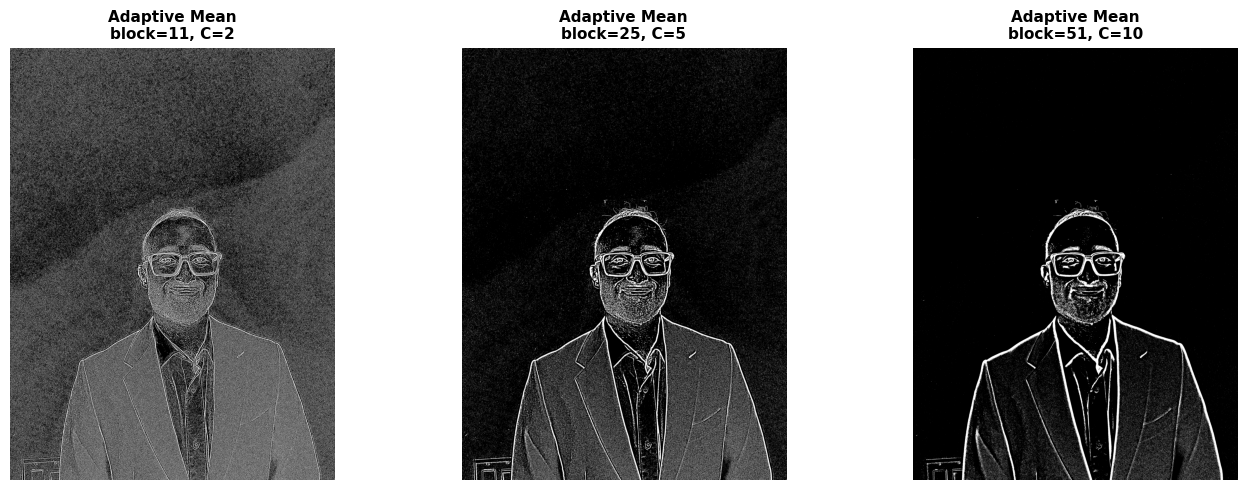

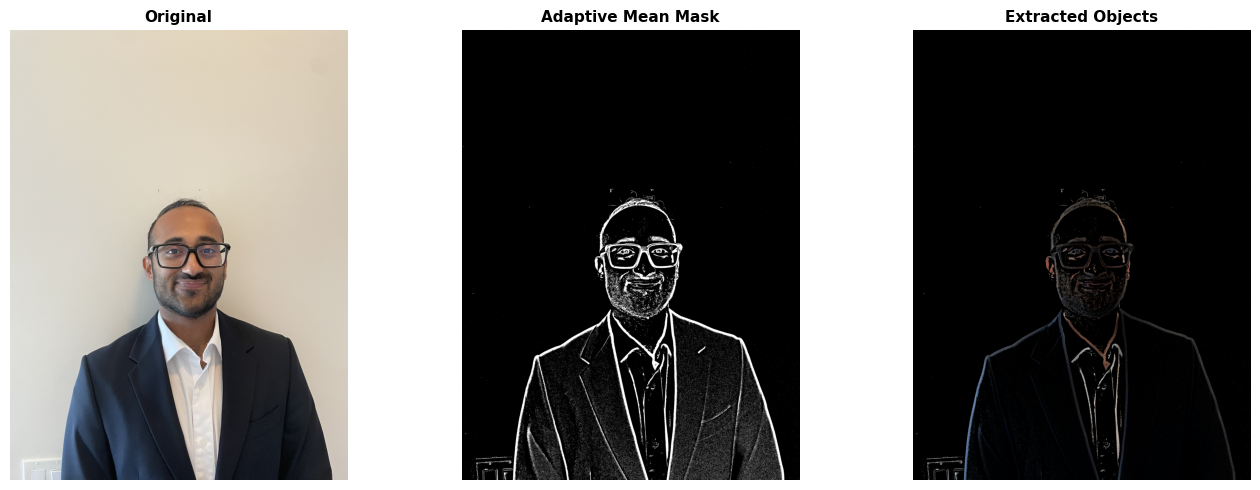

In [18]:
# blockSize must be odd; C is subtracted from the local mean
results, titles = [], []
for block, C in [(11, 2), (25, 5), (51, 10)]:
    mask = cv2.adaptiveThreshold(
        img_gray, 255,
        cv2.ADAPTIVE_THRESH_MEAN_C,
        cv2.THRESH_BINARY_INV,
        blockSize=block, C=C
    )
    results.append(mask)
    titles.append(f'Adaptive Mean\nblock={block}, C={C}')

show_images(results, titles, rows=1, cols=3, figsize=(14, 5))

# Best parameters for this image
mask_adapt_mean = cv2.adaptiveThreshold(
    img_gray, 255,
    cv2.ADAPTIVE_THRESH_MEAN_C,
    cv2.THRESH_BINARY_INV,
    blockSize=51, C=10
)
extracted_mean = cv2.bitwise_and(img_bgr, img_bgr, mask=mask_adapt_mean)
show_images([img_bgr, mask_adapt_mean, extracted_mean],
            ['Original', 'Adaptive Mean Mask', 'Extracted Objects'],
            rows=1, cols=3, figsize=(14, 5))

## 7. Technique 4 — Adaptive Gaussian Thresholding

Same as adaptive mean but the local threshold uses a **Gaussian-weighted sum** of the neighbourhood — pixels closer to the centre have more influence.  
This tends to produce **smoother, less noisy** masks than the mean variant.

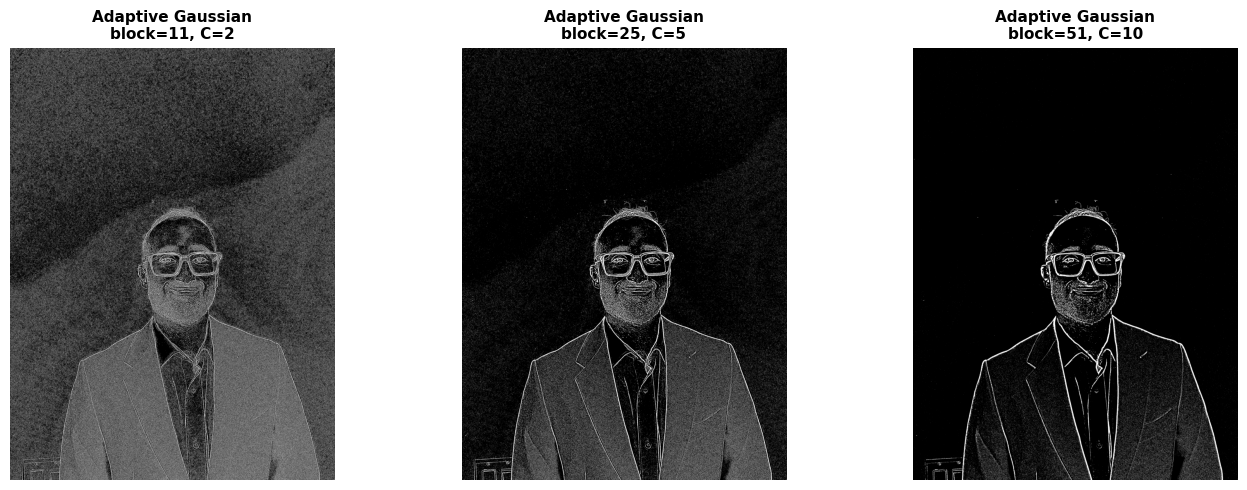

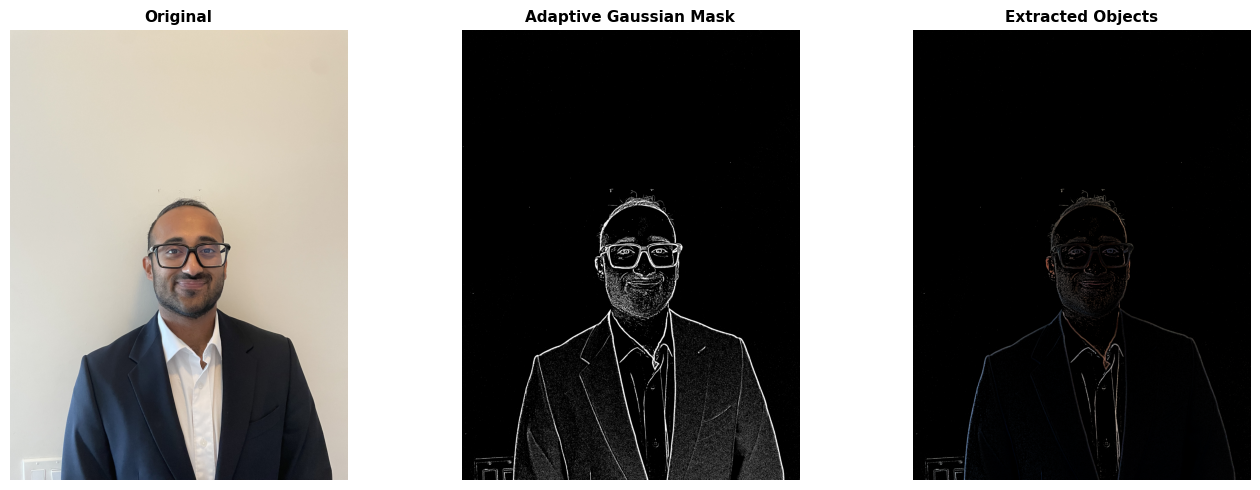

In [19]:
results, titles = [], []
for block, C in [(11, 2), (25, 5), (51, 10)]:
    mask = cv2.adaptiveThreshold(
        img_gray, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV,
        blockSize=block, C=C
    )
    results.append(mask)
    titles.append(f'Adaptive Gaussian\nblock={block}, C={C}')

show_images(results, titles, rows=1, cols=3, figsize=(14, 5))

# Best mask
mask_adapt_gauss = cv2.adaptiveThreshold(
    img_gray, 255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY_INV,
    blockSize=51, C=10
)
extracted_gauss = cv2.bitwise_and(img_bgr, img_bgr, mask=mask_adapt_gauss)
show_images([img_bgr, mask_adapt_gauss, extracted_gauss],
            ['Original', 'Adaptive Gaussian Mask', 'Extracted Objects'],
            rows=1, cols=3, figsize=(14, 5))

## 8. Technique 5 — HSV Colour-Range Thresholding

For coloured objects on a neutral (gray/white) background, we can define HSV ranges specific to each object's colour and produce individual masks. `cv2.inRange()` returns 255 for pixels inside the range and 0 otherwise.

| Object | Hue range (0–179) | Description |
|--------|------------------|-------------|
| Red apple | 0–10 and 160–179 | Red wraps around hue = 0 |
| Blue book | 100–130 | Classic blue range |
| Yellow banana | 20–35 | Yellow/gold range |

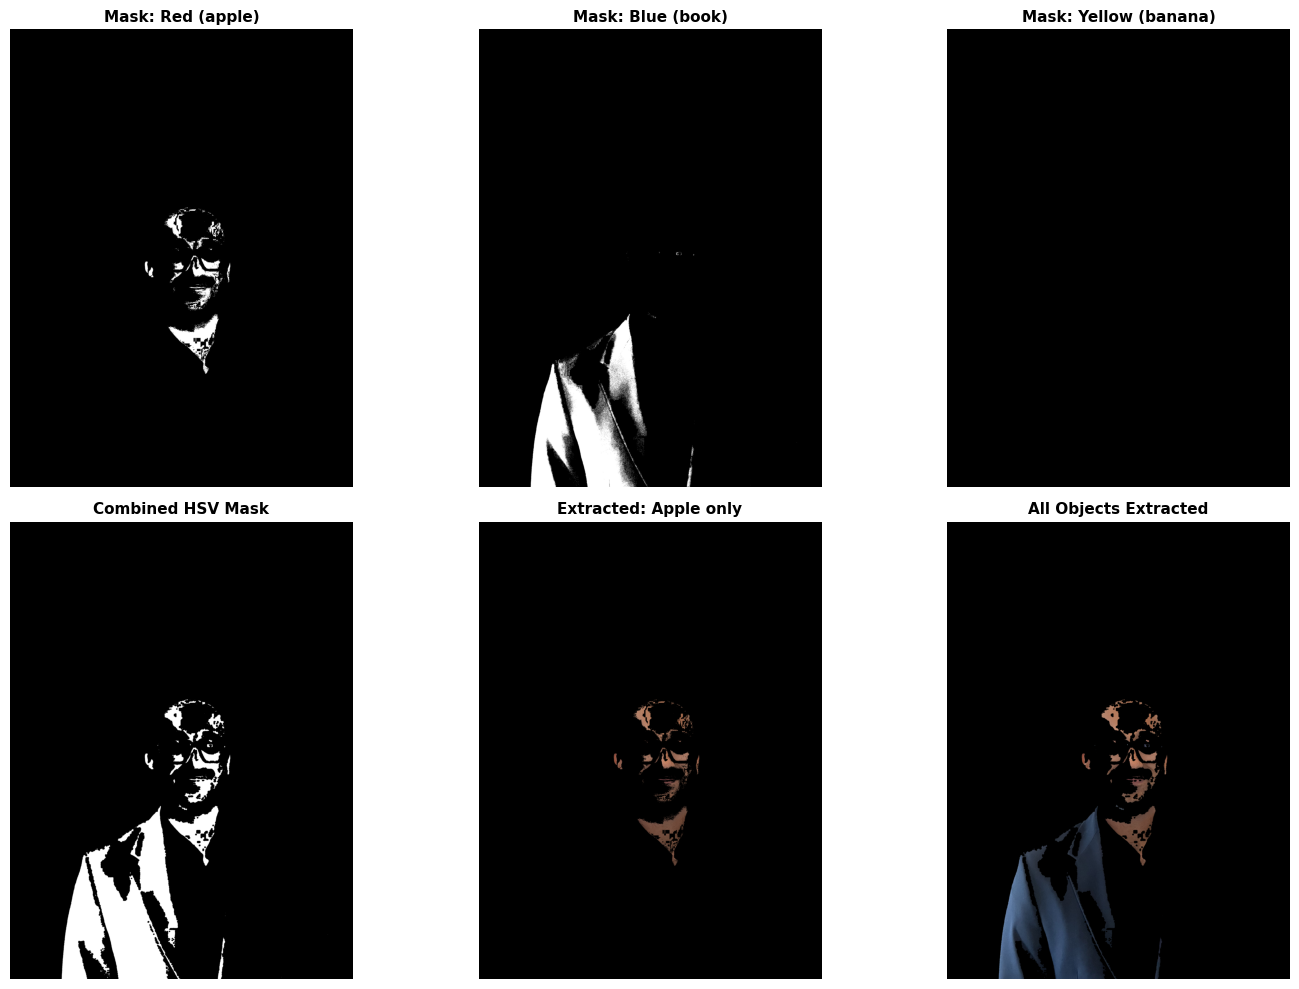

In [20]:
# ── Mask each object by HSV colour range ─────────────────────────────────────

# Red (hue wraps around 0° — must combine two ranges)
mask_red1 = cv2.inRange(img_hsv, (  0, 100,  80), ( 10, 255, 255))
mask_red2 = cv2.inRange(img_hsv, (160, 100,  80), (179, 255, 255))
mask_red  = cv2.bitwise_or(mask_red1, mask_red2)

# Blue
mask_blue = cv2.inRange(img_hsv, (100,  80,  50), (130, 255, 255))

# Yellow
mask_yellow = cv2.inRange(img_hsv, (20, 100, 100), (35, 255, 255))

# Combined: all objects at once
mask_all_hsv = cv2.bitwise_or(mask_red, cv2.bitwise_or(mask_blue, mask_yellow))

# ── Clean up with morphological operations ───────────────────────────────────
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
for name, m in [('red', mask_red), ('blue', mask_blue), ('yellow', mask_yellow)]:
    # Fill small holes inside the object
    m = cv2.morphologyEx(m, cv2.MORPH_CLOSE, kernel, iterations=2)
    # Remove stray noise pixels
    m = cv2.morphologyEx(m, cv2.MORPH_OPEN,  kernel, iterations=1)

mask_all_hsv_clean = cv2.morphologyEx(mask_all_hsv, cv2.MORPH_CLOSE, kernel, iterations=2)

# ── Visualise individual and combined masks ───────────────────────────────────
show_images(
    [mask_red, mask_blue, mask_yellow, mask_all_hsv_clean,
     cv2.bitwise_and(img_bgr, img_bgr, mask=mask_red),
     cv2.bitwise_and(img_bgr, img_bgr, mask=mask_all_hsv_clean)],
    ['Mask: Red (apple)', 'Mask: Blue (book)', 'Mask: Yellow (banana)',
     'Combined HSV Mask', 'Extracted: Apple only', 'All Objects Extracted'],
    rows=2, cols=3, figsize=(15, 10)
)

## 9. Technique 6 — Combined / Multi-Channel Thresholding

We can improve robustness by **combining** a grayscale-based mask (Otsu) with the HSV colour mask using a bitwise OR.  
This captures objects that may be missed by one method alone.

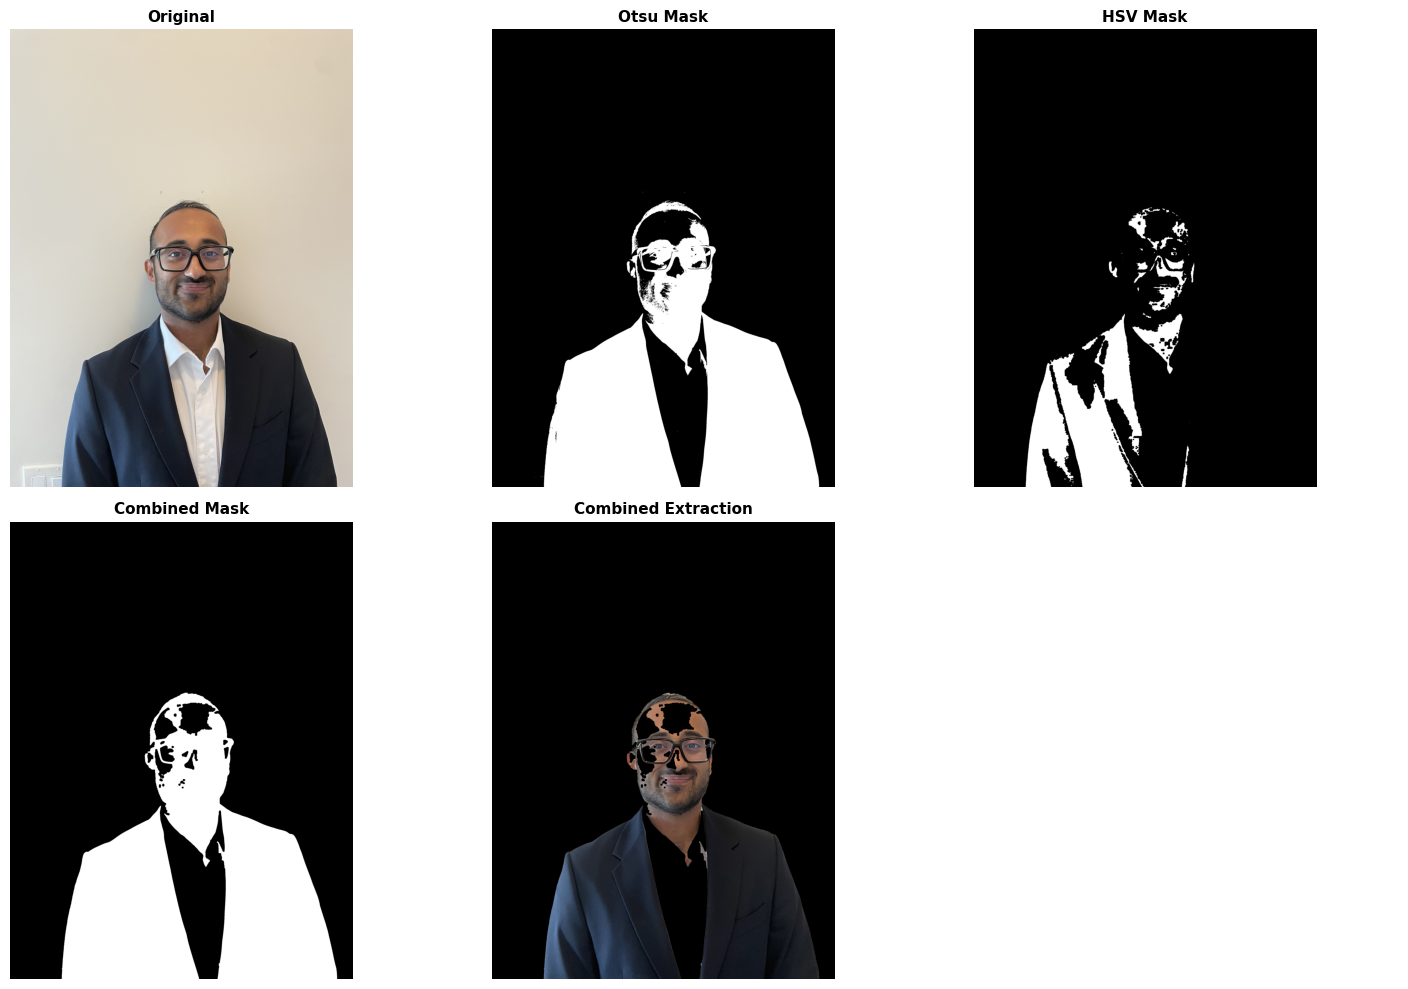

In [21]:
# Use Otsu (already computed) + HSV combined mask
mask_combined = cv2.bitwise_or(mask_otsu_blur, mask_all_hsv_clean)

# Morphological clean-up
kernel2 = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (9, 9))
mask_combined = cv2.morphologyEx(mask_combined, cv2.MORPH_CLOSE, kernel2, iterations=2)
mask_combined = cv2.morphologyEx(mask_combined, cv2.MORPH_OPEN,  kernel2, iterations=1)

extracted_combined = cv2.bitwise_and(img_bgr, img_bgr, mask=mask_combined)

show_images(
    [img_bgr, mask_otsu_blur, mask_all_hsv_clean, mask_combined,
     extracted_combined],
    ['Original', "Otsu Mask", 'HSV Mask', 'Combined Mask',
     'Combined Extraction'],
    rows=2, cols=3, figsize=(15, 10)
)

## 10. Final Comparison — All Techniques Side-by-Side

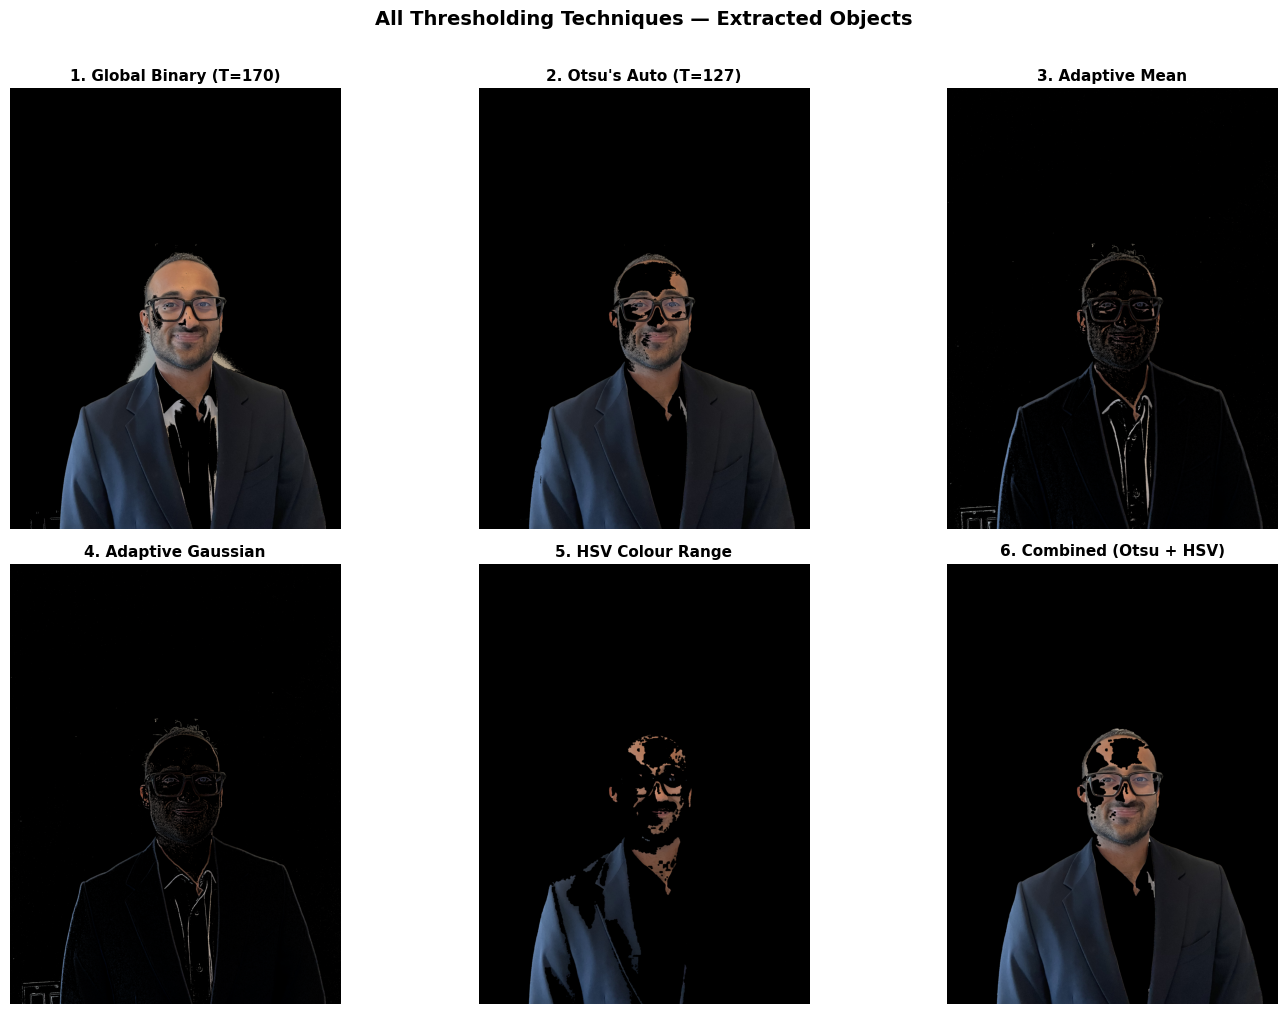

Technique                             Foreground px   Coverage %
-----------------------------------------------------------------
1. Global Binary (T=170)                  3,210,867        26.3%
2. Otsu's Auto (T=127)                    2,874,910        23.6%
3. Adaptive Mean                            625,007         5.1%
4. Adaptive Gaussian                        474,557         3.9%
5. HSV Colour Range                         980,391         8.0%
6. Combined (Otsu + HSV)                  2,950,531        24.2%


In [22]:
all_masks = [
    best_global,
    mask_otsu_blur,
    mask_adapt_mean,
    mask_adapt_gauss,
    mask_all_hsv_clean,
    mask_combined,
]
all_labels = [
    f'1. Global Binary (T={BEST_T})',
    f"2. Otsu's Auto (T={otsu_T2:.0f})",
    '3. Adaptive Mean',
    '4. Adaptive Gaussian',
    '5. HSV Colour Range',
    '6. Combined (Otsu + HSV)',
]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for ax, mask, title in zip(axes.flatten(), all_masks, all_labels):
    extracted = cv2.bitwise_and(img_bgr, img_bgr, mask=mask)
    ax.imshow(cv2.cvtColor(extracted, cv2.COLOR_BGR2RGB))
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.axis('off')
plt.suptitle('All Thresholding Techniques — Extracted Objects', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# ── Mask coverage statistics ─────────────────────────────────────────────────
total_px = img_gray.size
print(f"{'Technique':<35} {'Foreground px':>15} {'Coverage %':>12}")
print('-' * 65)
for mask, title in zip(all_masks, all_labels):
    fg = np.count_nonzero(mask)
    print(f"{title:<35} {fg:>15,} {fg/total_px*100:>11.1f}%")

## 11. Summary & Observations

| Technique | How it works | Pros | Cons |
|-----------|-------------|------|------|
| **Global Binary** | Single fixed T applied everywhere | Simple, fast | Fails with uneven lighting |
| **Otsu's Method** | Automatically finds best global T | No manual tuning needed | Still global — uneven lighting hurts |
| **Adaptive Mean** | Local threshold = mean of neighbourhood − C | Handles uneven lighting | Can produce noisy thin edges |
| **Adaptive Gaussian** | Local threshold = Gaussian-weighted mean − C | Smoother edges than mean | Slightly blurred boundaries |
| **HSV Colour Range** | Threshold in HSV colour space per object | Great for distinct colours | Requires knowing object colours in advance |
| **Combined** | Logical OR of Otsu + HSV | Best coverage, robust | More complex to tune |

### Key Takeaways
- For **homogenous neutral backgrounds**, Otsu's thresholding often works without any manual tuning.
- **Adaptive thresholding** shines when the background brightness is not perfectly uniform (common in real photos with shadows).
- **HSV colour thresholding** is the most targeted technique when objects have distinct hues — it can isolate individual objects while ignoring everything else.
- **Morphological post-processing** (closing + opening) is always recommended to fill holes in the mask and remove small noise pixels.
- Combining techniques gives the most reliable results for complex real-world images.

In [23]:
# Save best extraction to disk
cv2.imwrite('extracted_objects_final.jpg', extracted_combined)
print('Saved: extracted_objects_final.jpg')

Saved: extracted_objects_final.jpg
